# Exploratory Data Analysis

## 1. Setup

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

ROOT = Path.cwd()
if not (ROOT / "data" / "raw").exists():
    ROOT = ROOT.parent

RAW_DATA_PATH = ROOT / "data" / "raw"
PROCESSED_DATA_PATH = ROOT / "data" / "processed"

RAW_DATA_PATH.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_PATH.mkdir(parents=True, exist_ok=True)
application_train = pd.read_csv(RAW_DATA_PATH / "application_train.csv")
application_test = pd.read_csv(RAW_DATA_PATH / "application_test.csv")


## 2. Data Overview

In [37]:
print(f"application_train's shape {application_train.shape}")
print(f"application_test's shape {application_test.shape}")
print(f"application_train's default rate {application_train['TARGET'].mean()}")

missing_summary = pd.DataFrame({
    "missing_count": application_train.isna().sum(),
    "missing_percent": application_train.isna().mean() * 100
})

missing_summary = missing_summary.sort_values(
    "missing_percent",
    ascending=False
)

display(missing_summary.head(10))

target_col = "TARGET"
id_cols = ["SK_ID_CURR"]

categorical_cols = application_train.select_dtypes(include=["object", "string", "category"]).columns.tolist()

numeric_cols = application_train.select_dtypes(include=["number"]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in id_cols + [target_col]]

binary_cols = [
    c for c in numeric_cols
    if application_train[c].dropna().nunique() == 2
]

low_cardinality_numeric_cols = [
    c for c in numeric_cols
    if 2 < application_train[c].dropna().nunique() <= 20
]

continuous_cols = [
    c for c in numeric_cols
    if c not in binary_cols + low_cardinality_numeric_cols
]

print("Categorical object columns:", len(categorical_cols))
print("Binary numeric columns:", len(binary_cols))
print("Low-cardinality numeric columns:", len(low_cardinality_numeric_cols))
print("Continuous numeric columns:", len(continuous_cols))

application_train's shape (307511, 122)
application_test's shape (48744, 121)
application_train's default rate 0.08072881945686496


,missing_count,missing_percent
COMMONAREA_MEDI,214865,69.872297
COMMONAREA_AVG,214865,69.872297
COMMONAREA_MODE,214865,69.872297
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_MODE,210199,68.354953
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953


Categorical object columns: 16
Binary numeric columns: 32
Low-cardinality numeric columns: 10
Continuous numeric columns: 62


## 3. Categorical Columns

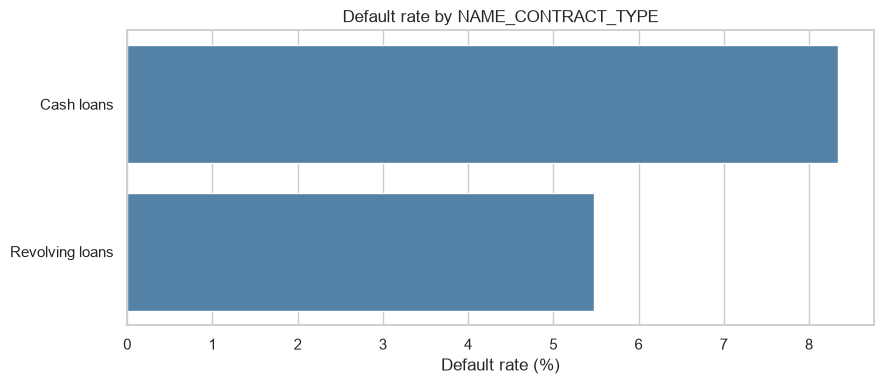

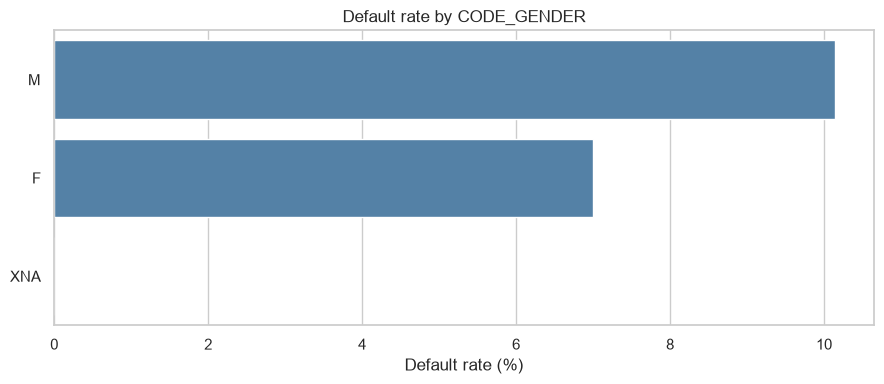

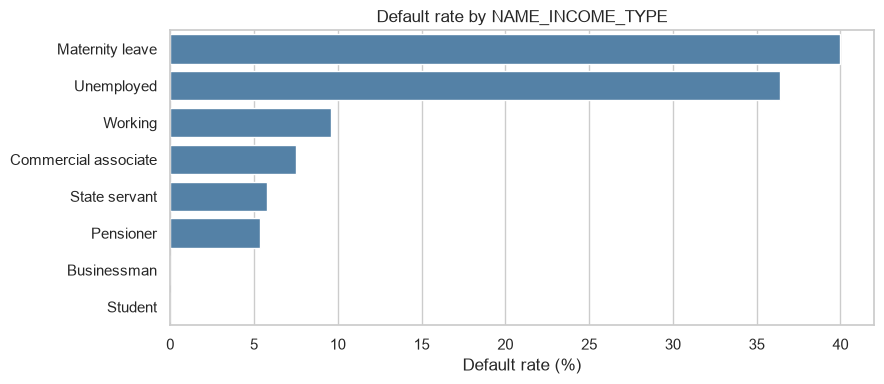

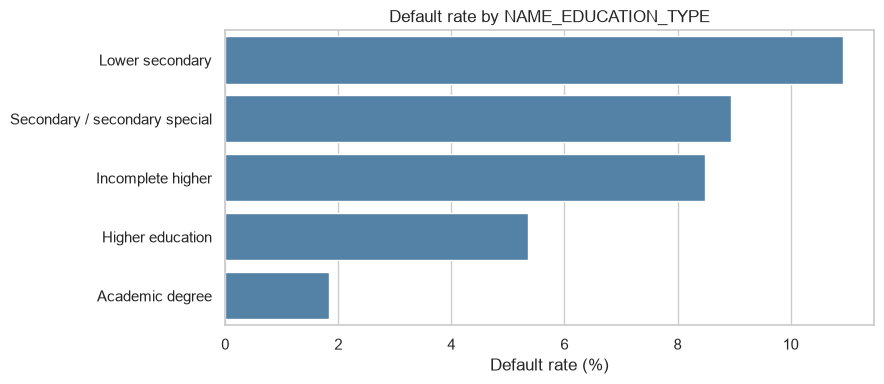

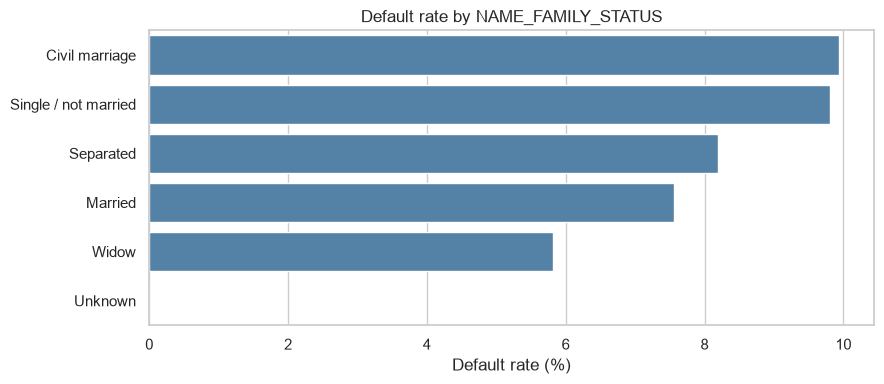

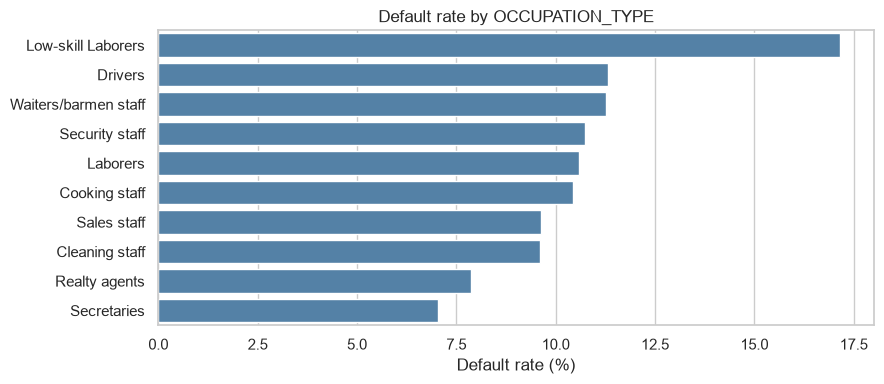

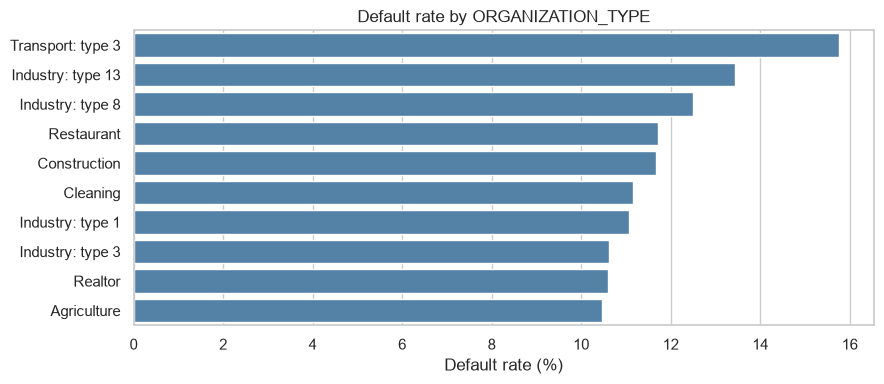

In [38]:
important_categorical_cols = [
    "NAME_CONTRACT_TYPE",
    "CODE_GENDER",
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "OCCUPATION_TYPE",
    "ORGANIZATION_TYPE",
]

important_categorical_cols = [col for col in important_categorical_cols]

for col in important_categorical_cols:
    category_summary = (
        application_train
        .groupby(col, dropna=False)[target_col]
        .agg(count="size", default_rate="mean")
        .sort_values("default_rate", ascending=False)
    )
    category_summary["default_rate"] *= 100

    plot_data = category_summary.reset_index().head(10)
    plot_data[col] = plot_data[col].astype(str)

    plt.figure(figsize=(9, 4))
    sns.barplot(data=plot_data, x="default_rate", y=col, color="steelblue")
    plt.title(f"Default rate by {col}")
    plt.xlabel("Default rate (%)")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

## 4. Numerical Columns

,count,mean,std,min,1%,5%,50%,95%,99%,max
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,2.565000e+04,45000.000000,67500.000000,147150.000000,3.375000e+05,4.725000e+05,1.170000e+08
AMT_CREDIT,307511.0,599025.999706,402490.776996,4.500000e+04,76410.000000,135000.000000,513531.000000,1.350000e+06,1.854000e+06,4.050000e+06
AMT_ANNUITY,307499.0,27108.573909,14493.737315,1.615500e+03,6182.910000,9000.000000,24903.000000,5.332500e+04,7.000650e+04,2.580255e+05
AMT_GOODS_PRICE,307233.0,538396.207429,369446.460540,4.050000e+04,67500.000000,135000.000000,450000.000000,1.305000e+06,1.800000e+06,4.050000e+06
DAYS_BIRTH,307511.0,-16036.995067,4363.988632,-2.522900e+04,-24419.000000,-23204.000000,-15750.000000,-9.407000e+03,-8.263000e+03,-7.489000e+03
DAYS_EMPLOYED,307511.0,63815.045904,141275.766519,-1.791200e+04,-10894.900000,-6742.500000,-1213.000000,3.652430e+05,3.652430e+05,3.652430e+05
EXT_SOURCE_1,134133.0,0.502130,0.211062,1.456813e-02,0.084257,0.158021,0.505998,8.322601e-01,8.894105e-01,9.626928e-01
EXT_SOURCE_2,306851.0,0.514393,0.191060,8.173617e-08,0.029477,0.133299,0.565961,7.477341e-01,7.827928e-01,8.549997e-01
EXT_SOURCE_3,246546.0,0.510853,0.194844,5.272652e-04,0.064672,0.154744,0.535276,7.862666e-01,8.327850e-01,8.960095e-01


,non_default_median,default_median
AMT_INCOME_TOTAL,148500.000000,135000.000000
AMT_CREDIT,517788.000000,497520.000000
AMT_ANNUITY,24876.000000,25263.000000
AMT_GOODS_PRICE,450000.000000,450000.000000
DAYS_BIRTH,-15877.000000,-14282.000000
DAYS_EMPLOYED,-1235.000000,-1034.000000
EXT_SOURCE_1,0.517452,0.361675
EXT_SOURCE_2,0.573905,0.440381
EXT_SOURCE_3,0.546023,0.379100


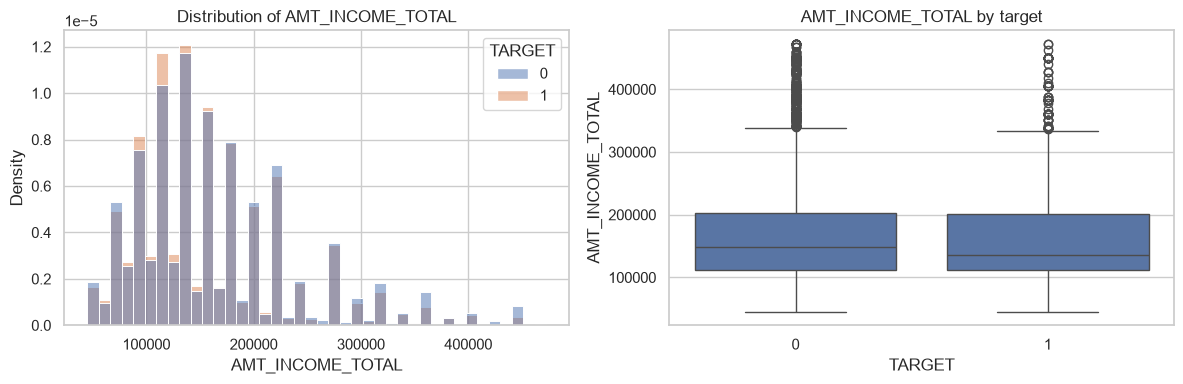

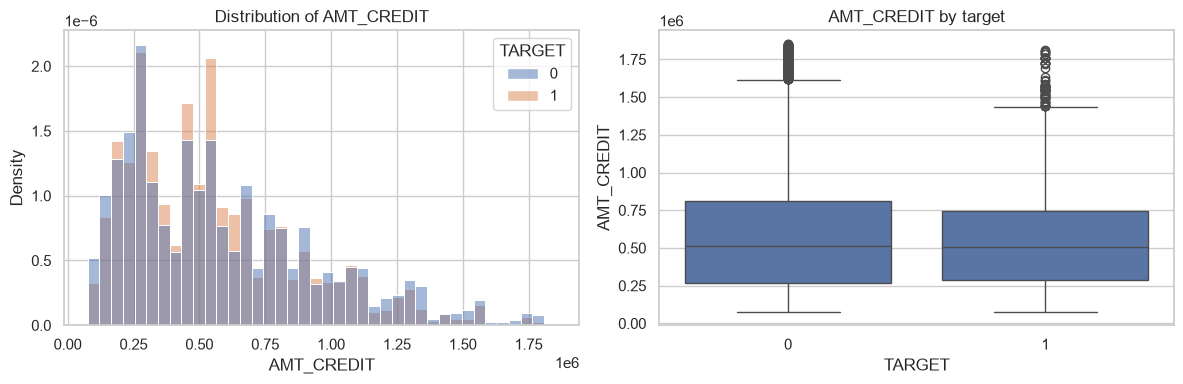

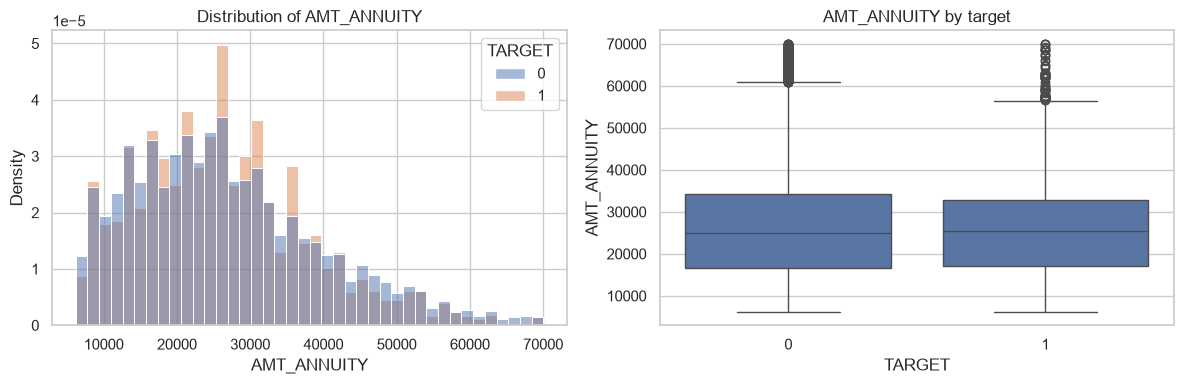

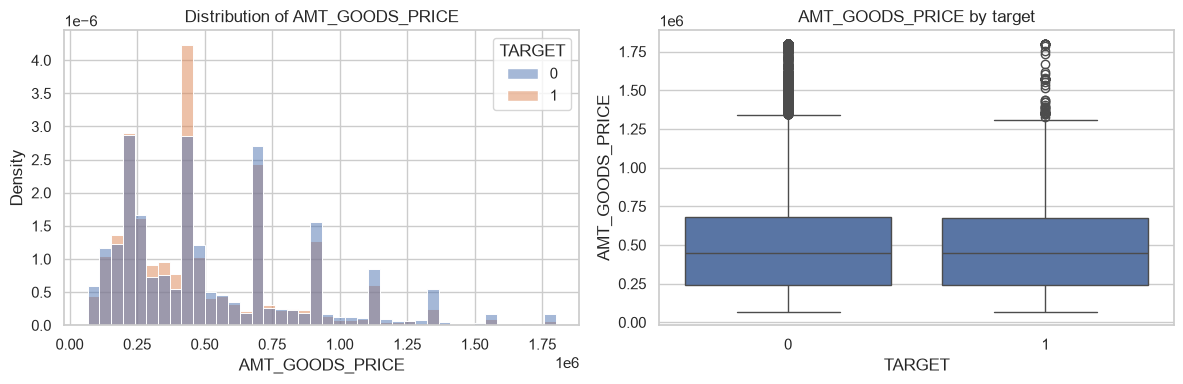

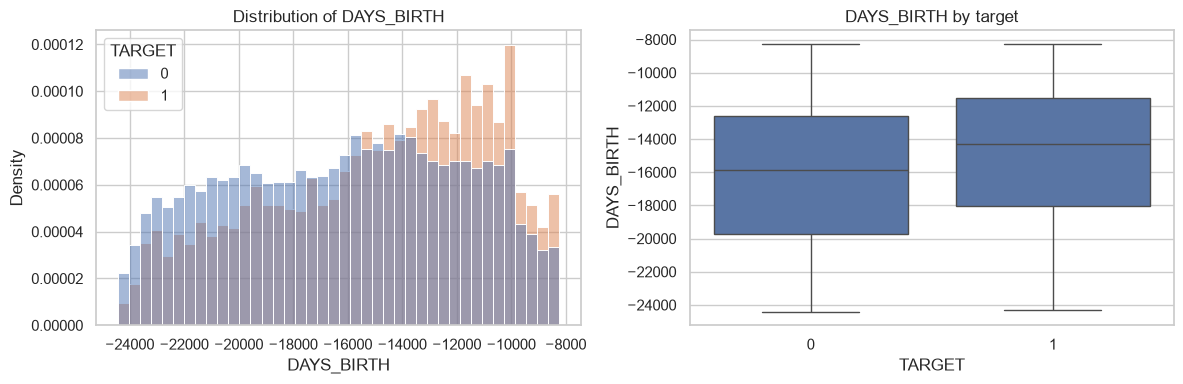

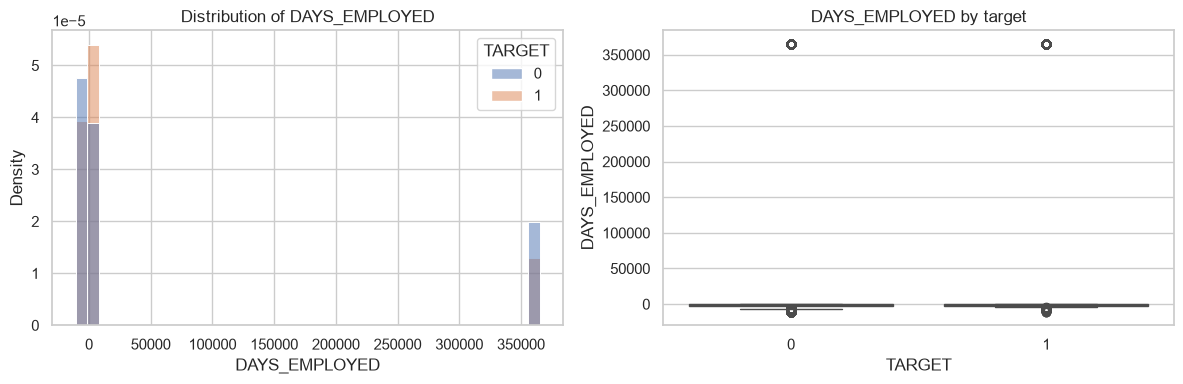

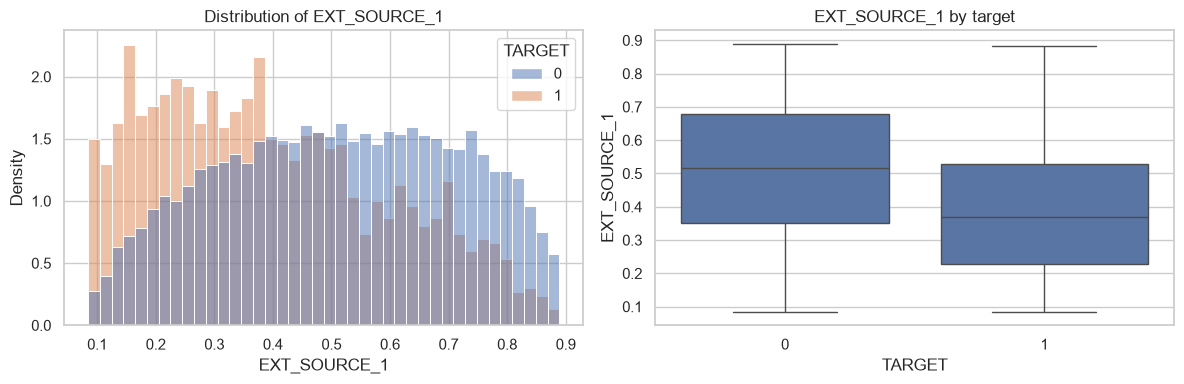

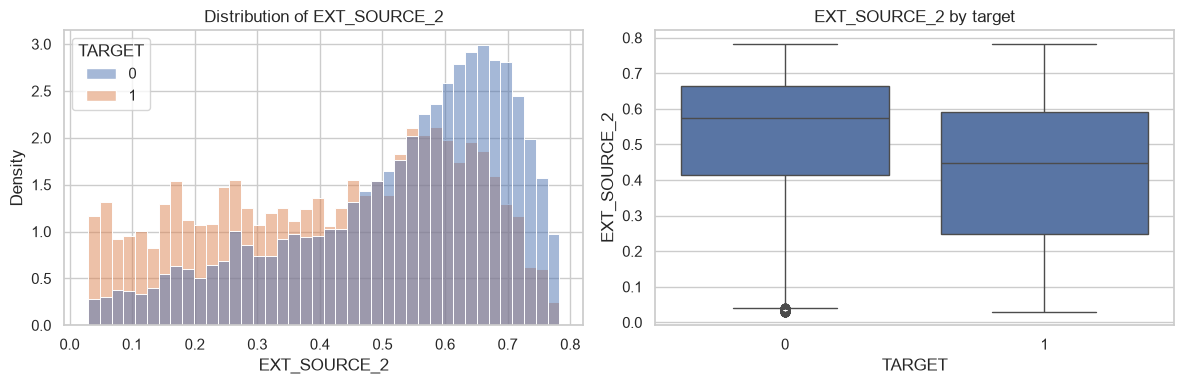

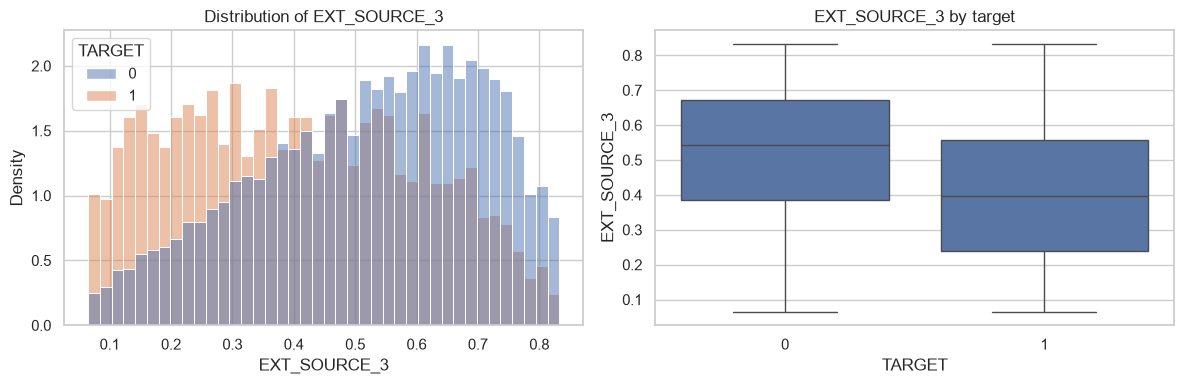

In [41]:
important_numeric_cols = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
]

important_numeric_cols = [col for col in important_numeric_cols]

display(
    application_train[important_numeric_cols]
    .describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
    .T
)

numeric_by_target = application_train.groupby(target_col)[important_numeric_cols].median().T
numeric_by_target.columns = ["non_default_median", "default_median"]
display(numeric_by_target)

plot_sample = application_train[[target_col] + important_numeric_cols].sample(
    n=min(50000, len(application_train)),
    random_state=42,
)

for col in important_numeric_cols:
    lower = application_train[col].quantile(0.01)
    upper = application_train[col].quantile(0.99)
    plot_data = plot_sample[[target_col, col]].dropna()
    plot_data = plot_data[plot_data[col].between(lower, upper)]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.histplot(
        data=plot_data,
        x=col,
        hue=target_col,
        bins=40,
        stat="density",
        common_norm=False,
        ax=axes[0],
    )
    axes[0].set_title(f"Distribution of {col}")

    sns.boxplot(data=plot_data, x=target_col, y=col, ax=axes[1])
    axes[1].set_title(f"{col} by target")
    axes[1].set_xlabel("TARGET")

    plt.tight_layout()
    plt.show()

## 5. Correlation Among Variables

,correlation_with_target
EXT_SOURCE_3,-0.178919
EXT_SOURCE_2,-0.160472
EXT_SOURCE_1,-0.155317
DAYS_BIRTH,0.078239
REGION_RATING_CLIENT_W_CITY,0.060893
REGION_RATING_CLIENT,0.058899
DAYS_LAST_PHONE_CHANGE,0.055218
DAYS_ID_PUBLISH,0.051457
REG_CITY_NOT_WORK_CITY,0.050994
FLAG_EMP_PHONE,0.045982


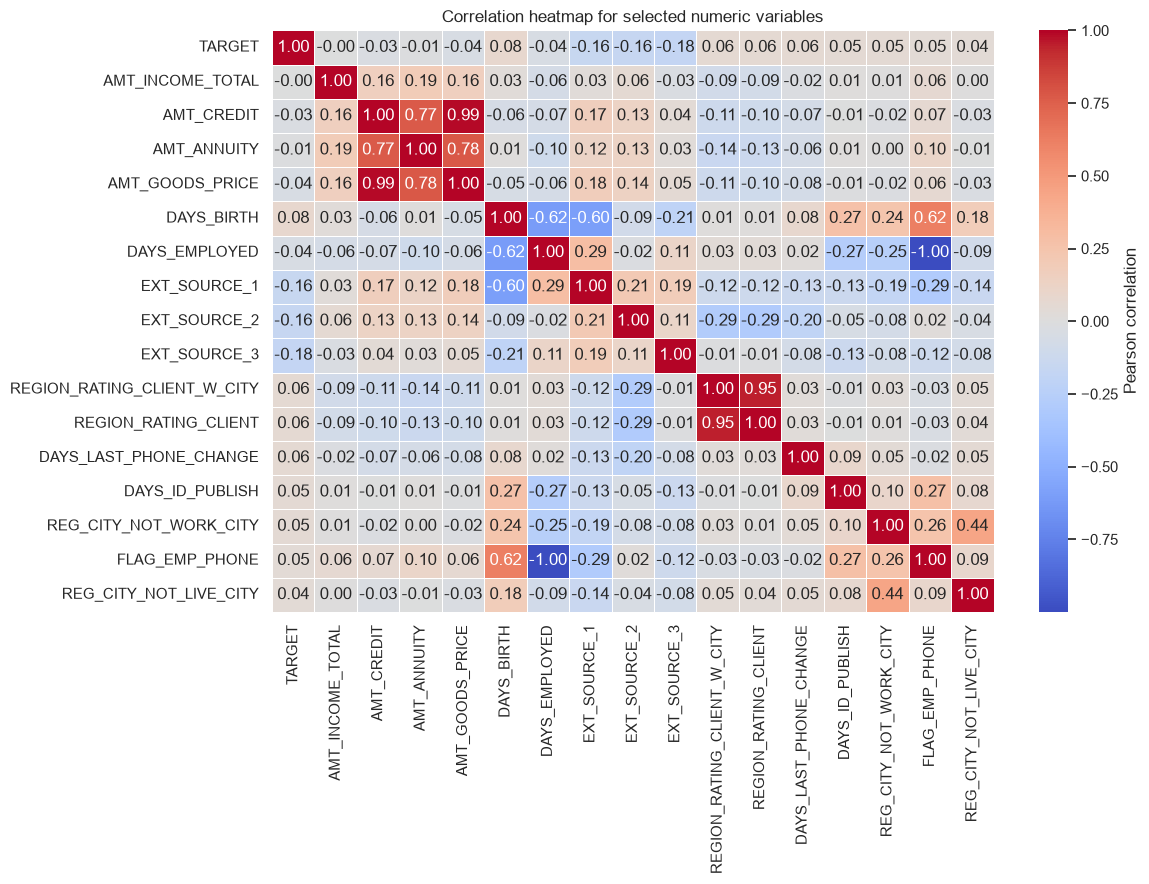

In [40]:
correlation_cols = [col for col in numeric_cols]

target_correlations = (
    application_train[correlation_cols + [target_col]]
    .corr(numeric_only=True)[target_col]
    .drop(target_col)
    .sort_values()
)

strongest_target_correlations = (
    target_correlations
    .abs()
    .sort_values(ascending=False)
    .head(20)
)

display(
    target_correlations
    .loc[strongest_target_correlations.index]
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .to_frame("correlation_with_target")
)

heatmap_cols = list(dict.fromkeys(
    [target_col]
    + important_numeric_cols
    + strongest_target_correlations.index.tolist()[:12]
))

heatmap_corr = application_train[heatmap_cols].corr(numeric_only=True)

plt.figure(figsize=(12, 9))
sns.heatmap(
    heatmap_corr,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Pearson correlation"},
)
plt.title("Correlation heatmap for selected numeric variables")
plt.tight_layout()
plt.show()
